# Per-Class Performance: Visual Analysis
Reuses the predictions already cached by the SigTest notebooks -- no models,
no GPU needed here. Produces two figures for the thesis:
1. A heatmap of per-class F1-score across all 6 single models + the proposed ensemble
2. A bar chart comparing the best single model vs the proposed ensemble, per class,
   to show exactly where ensembling helps most.

## Cell 1 — Setup + load cached predictions

In [1]:
import numpy as np
import pandas as pd
import json as jsonlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

from google.colab import drive
drive.mount('/content/drive')

cache = '/content/drive/MyDrive/thesis_ensemble_outputs/significance_test_cache'

pred_swin = np.load(f'{cache}/pred_swin.npy')
pred_vit = np.load(f'{cache}/pred_vit.npy')
pred_resnet = np.load(f'{cache}/pred_resnet.npy')
pred_densenet = np.load(f'{cache}/pred_densenet.npy')
pred_efficientnet = np.load(f'{cache}/pred_efficientnet.npy')
pred_levit = np.load(f'{cache}/pred_levit.npy')
ensemble_probs = np.load(f'{cache}/ensemble_probs.npy')
true_labels = np.load(f'{cache}/true_labels.npy')
with open(f'{cache}/class_names.json') as f:
    class_names = jsonlib.load(f)

print("Loaded. Classes:", class_names)

Mounted at /content/drive
Loaded. Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 2 — Compute per-class F1 for every model

In [2]:
models_preds = {
    "Swin": pred_swin,
    "ViT": pred_vit,
    "LeViT": pred_levit,
    "ResNet50": pred_resnet,
    "DenseNet121": pred_densenet,
    "EfficientNetB0": pred_efficientnet,
    "Proposed Ensemble": ensemble_probs,
}

f1_table = pd.DataFrame(index=class_names)

for model_name, preds in models_preds.items():
    pred_labels = np.argmax(preds, axis=1)
    report = classification_report(true_labels, pred_labels, target_names=class_names, output_dict=True, zero_division=0)
    f1_table[model_name] = [report[cls]['f1-score'] for cls in class_names]

f1_table = f1_table.round(3)
print(f1_table.to_string())

                             Swin    ViT  LeViT  ResNet50  DenseNet121  EfficientNetB0  Proposed Ensemble
Corn_Common_Rust            0.987  0.982  0.977     0.992        0.975           0.982              0.992
Corn_Gray_Leaf_Spot         0.969  0.950  0.900     0.940        0.924           0.940              0.968
Corn_Healthy                0.997  1.000  0.989     1.000        0.997           0.997              1.000
Corn_Leaf_Blight            0.959  0.947  0.889     0.937        0.915           0.937              0.969
Rice_Bacterial_Leaf_Blight  0.983  0.988  0.951     0.985        0.978           0.986              0.991
Rice_Brown_Spot             0.985  0.976  0.961     0.989        0.968           0.979              0.991
Rice_Healthy                0.991  0.995  0.975     0.988        0.988           0.992              0.995
Rice_Leaf_Blast             0.965  0.977  0.907     0.967        0.954           0.961              0.975
Wheat_Brown_Rust            0.995  0.984  0.94

## Cell 3 — Heatmap: per-class F1 across all models

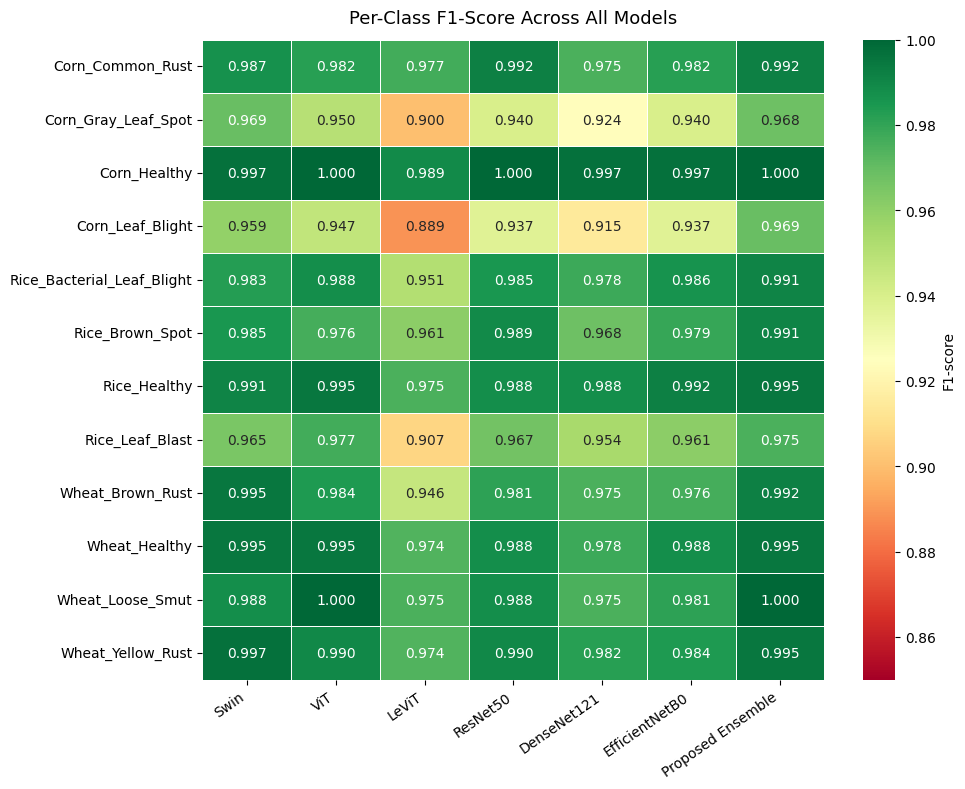

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/per_class_f1_heatmap.png


In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(f1_table, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.85, vmax=1.0,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'F1-score'})
plt.title('Per-Class F1-Score Across All Models', fontsize=13, pad=12)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
plt.savefig(f'{output_folder}/per_class_f1_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/per_class_f1_heatmap.png")

## Cell 4 — Bar chart: best single model vs proposed ensemble, per class
Shows exactly which classes benefit most (and least, or even negatively) from
ensembling -- directly answers "where does the ensemble actually help?".

Best-performing single model overall: Swin


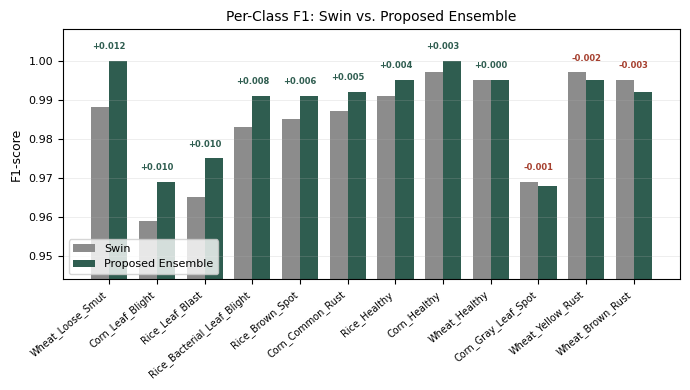

Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/per_class_gain_barchart.png

Per-class gain (ensemble - best single), sorted:
                             Gain
Wheat_Loose_Smut            0.012
Corn_Leaf_Blight            0.010
Rice_Leaf_Blast             0.010
Rice_Bacterial_Leaf_Blight  0.008
Rice_Brown_Spot             0.006
Corn_Common_Rust            0.005
Rice_Healthy                0.004
Corn_Healthy                0.003
Wheat_Healthy               0.000
Corn_Gray_Leaf_Spot        -0.001
Wheat_Yellow_Rust          -0.002
Wheat_Brown_Rust           -0.003


In [5]:
best_single_name = f1_table.drop(columns=['Proposed Ensemble']).mean(axis=0).idxmax()
print(f"Best-performing single model overall: {best_single_name}")

compare_df = f1_table[[best_single_name, 'Proposed Ensemble']].copy()
compare_df['Gain'] = compare_df['Proposed Ensemble'] - compare_df[best_single_name]
compare_df = compare_df.sort_values('Gain', ascending=False)

x = np.arange(len(compare_df))
width = 0.38

# Compact size for a paper figure -- adjust figsize to your journal's column width
# (e.g. (3.5, 3) for single-column IEEE, (7, 4) for double-column / full width)
fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, compare_df[best_single_name], width, label=best_single_name, color='#8C8C8C')
bars2 = ax.bar(x + width/2, compare_df['Proposed Ensemble'], width, label='Proposed Ensemble', color='#2F5D50')

ax.set_ylabel('F1-score', fontsize=9)
ax.set_title(f'Per-Class F1: {best_single_name} vs. Proposed Ensemble', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=40, ha='right', fontsize=7)
ax.tick_params(axis='y', labelsize=8)

y_min = min(compare_df[best_single_name].min(), compare_df['Proposed Ensemble'].min()) - 0.015
ax.set_ylim(max(y_min, 0), 1.008)
ax.legend(fontsize=8, loc='lower left')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)

for i, gain in enumerate(compare_df['Gain']):
    color = '#2F5D50' if gain >= 0 else '#A6402F'
    top = max(compare_df[best_single_name].iloc[i], compare_df['Proposed Ensemble'].iloc[i])
    ax.annotate(f'{gain:+.3f}', (x[i], top + 0.003),
                ha='center', fontsize=6, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{output_folder}/per_class_gain_barchart.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to: {output_folder}/per_class_gain_barchart.png")

print("\nPer-class gain (ensemble - best single), sorted:")
print(compare_df[['Gain']].to_string())